### Verificando Imagens Corrompidas



In [7]:
import zipfile
import os
from PIL import Image
from google.colab import userdata


In [8]:
os.environ['Kaggle_User'] = userdata.get('Kaggle_User')
os.environ['Kaggle_Token'] = userdata.get('Kaggle_Token')


In [9]:
!kaggle datasets download -d marquis03/bean-leaf-lesions-classification

Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification
License(s): apache-2.0
100% 155M/155M [00:01<00:00, 114MB/s]



In [10]:
!unzip -q bean-leaf-lesions-classification.zip -d /content/bean_dataset

In [11]:
from PIL import  UnidentifiedImageError
import pandas as pd

## Acessando o diretorio do dataset

In [12]:
dataset_dir = '/content/bean_dataset'
corrupted_files = []

## Percorrendo todos os diretórios e subdiretórios do dataset

In [13]:
# Percorre todos os diretórios e subdiretórios do dataset
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')):
            file_path = os.path.join(root, file)
            try:
                # 1. Verifica se o cabeçalho do arquivo é válido
                with Image.open(file_path) as img:
                    img.verify()

                # 2. Reabre e força o carregamento dos dados para detectar imagens truncadas
                with Image.open(file_path) as img:
                    img.load()

            except (UnidentifiedImageError, OSError, SyntaxError, Exception) as e:
                # Se qualquer erro ocorrer, adiciona à lista de corrompidos
                corrupted_files.append((file_path, str(e)))

print(f"Total de imagens corrompidas encontradas: {len(corrupted_files)}")


for path, error in corrupted_files[:10]:
    print(f"• {path}\n  Erro: {error}")

Total de imagens corrompidas encontradas: 0


## Percorrendo todas as imagens

In [22]:
import pathlib as Path
import random

In [23]:
dataset_dir = '/content/bean_dataset'

# Lista todas as imagens recursivamente
todas_imagens = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')):
            caminho_completo = os.path.join(root, file)
            todas_imagens.append(caminho_completo)

print(f"📊 Total de imagens encontradas: {len(todas_imagens)}\n")

# Percorre todas as imagens
for idx, img_path in enumerate(todas_imagens, 1):
    # Extrai informações
    nome_arquivo = os.path.basename(img_path)
    classe = os.path.basename(os.path.dirname(img_path))
    tamanho = os.path.getsize(img_path) / 1024  # em KB


    print(f"[{idx}/{len(todas_imagens)}] {classe}/{nome_arquivo} ({tamanho:.1f} KB)")



📊 Total de imagens encontradas: 1167

[1/1167] bean_rust/bean_rust_val.41.jpg (136.7 KB)
[2/1167] bean_rust/bean_rust_val.22.jpg (126.4 KB)
[3/1167] bean_rust/bean_rust_val.9.jpg (144.7 KB)
[4/1167] bean_rust/bean_rust_val.19.jpg (144.9 KB)
[5/1167] bean_rust/bean_rust_val.27.jpg (129.5 KB)
[6/1167] bean_rust/bean_rust_val.15.jpg (116.6 KB)
[7/1167] bean_rust/bean_rust_val.2.jpg (122.8 KB)
[8/1167] bean_rust/bean_rust_val.25.jpg (112.4 KB)
[9/1167] bean_rust/bean_rust_val.6.jpg (110.8 KB)
[10/1167] bean_rust/bean_rust_val.18.jpg (173.8 KB)
[11/1167] bean_rust/bean_rust_val.17.jpg (168.6 KB)
[12/1167] bean_rust/bean_rust_val.16.jpg (135.6 KB)
[13/1167] bean_rust/bean_rust_val.40.jpg (111.6 KB)
[14/1167] bean_rust/bean_rust_val.11.jpg (129.0 KB)
[15/1167] bean_rust/bean_rust_val.44.jpg (111.7 KB)
[16/1167] bean_rust/bean_rust_val.8.jpg (105.6 KB)
[17/1167] bean_rust/bean_rust_val.38.jpg (139.8 KB)
[18/1167] bean_rust/bean_rust_val.33.jpg (121.5 KB)
[19/1167] bean_rust/bean_rust_val.10.jp

## Mostrando 10 imagens aleatórias


In [24]:
import matplotlib.pyplot as plt
from PIL import Image

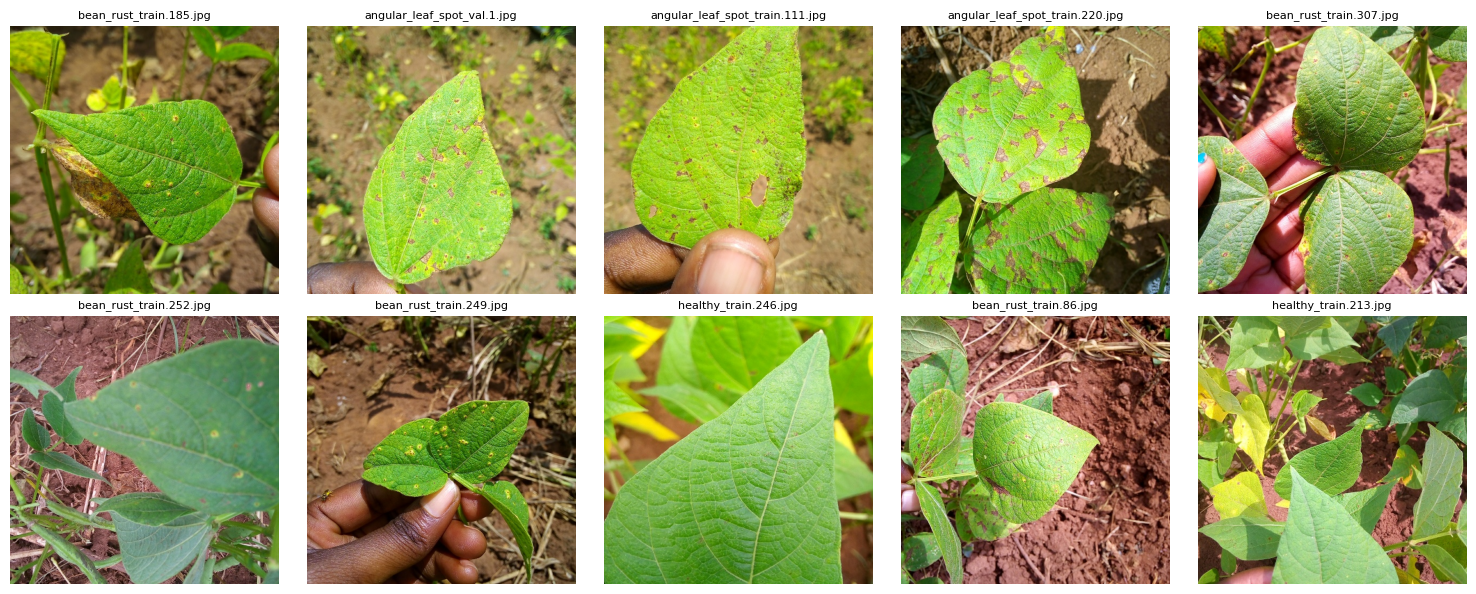

In [25]:
dataset_dir = '/content/bean_dataset'

# Coleta todas as imagens
todas_imagens = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')):
            todas_imagens.append(os.path.join(root, file))

# Seleciona 10 imagens aleatórias
imagens_selecionadas = random.sample(todas_imagens, min(10, len(todas_imagens)))

# Exibe as imagens
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_path in enumerate(imagens_selecionadas):
    img = Image.open(img_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(os.path.basename(img_path), fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Criando o arquivo gitignore

In [26]:
%%writefile .gitignore
bean_dataset/
*.zip
imagens_corrompidas.csv
__pycache__/
*.pyc
.DS_Store

Writing .gitignore
